# SEGWO Response Analysis — Publication-Ready Figures

This notebook generates all figures for the paper from pre-computed results stored in `./data`.
No heavy computation is performed here; every cell only loads arrays and produces plots.

In [1]:
import argparse
import os
import matplotlib.pyplot as plt
import h5py
import healpy as hp
import numpy as np
from tqdm import trange

from lisaorbits import StaticConstellation
from lisaconstants import c
from lisaconstants.indexing import LINKS
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo_utils import (InterpolatedOrbits, compute_strain2x, compute_covariance, compute_violation_ratios, get_static_variation, compute_orientation)

np.random.seed(2601)


# ---------------------------------------------------------------------------
# Frequency grid
# ---------------------------------------------------------------------------
f = np.logspace(-4, -2., 10)
f = np.append(f, np.logspace(-2., 0., 140))
f = np.unique(np.sort(f))

time_eval = 30.0
run_flag = ['static', 'evolving'][1]
array_ltts = np.asarray([time_eval * 86400])
boost_flag = float(1)
print(f"run_flag: {run_flag}  |  time_eval: {time_eval} days  |  boost_flag: {boost_flag}")

# ---------------------------------------------------------------------------
# Orbit setup
# ---------------------------------------------------------------------------
if run_flag == 'static':
    N = 1000
    orbits = StaticConstellation.from_armlengths(2.5e9, 2.5e9, 2.5e9)

if run_flag == 'evolving':
    
    with h5py.File("data/processed_trajectories.h5", "r") as ds:
        t_orb_dataset   = ds["t_interp"][()]
        x_orb_dataset   = ds["spacecraft_positions"][()]
        v_orb_dataset   = ds["spacecraft_velocities"][()]
        ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]

    t_orb        = t_orb_dataset
    x_orb        = np.median(x_orb_dataset, axis=0)
    v_orb        = np.median(v_orb_dataset, axis=0)
    ltts_median  = np.median(ltts_dataset,  axis=0)
    realizations = x_orb_dataset.shape[0]
    N            = realizations
    N = 1000
    print(f"Number of realizations: {realizations}")
    orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_flag: evolving  |  time_eval: 30.0 days  |  boost_flag: 1.0
Number of realizations: 1000


In [2]:
# ---------------------------------------------------------------------------
# Nominal orbit quantities
# ---------------------------------------------------------------------------
ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)
print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

# ---------------------------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------------------------
nside        = 8
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis

# ---------------------------------------------------------------------------
# Nominal strain-to-TDI matrix
# ---------------------------------------------------------------------------
print("Computing nominal strain2x …")
strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
print(f"strain2x_nominal shape: {strain2x_nominal.shape}")
cov_AET = compute_covariance(f, ltts)[:,:,np.newaxis,:,:] # added an axis for sky pixels
inv_cov_AET = np.linalg.inv(cov_AET)
print(f"cov_AET shape: {cov_AET.shape}")
strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)

# do not sum over polarizations and consider only pluse
h_h_plus = (4 * np.einsum("ijklm,ijklr,ijkrm->ijkm",np.conj(strain2AET), inv_cov_AET, strain2AET).real)[...,0]
h_h_cross = (4 * np.einsum("ijklm,ijklr,ijkrm->ijkm",np.conj(strain2AET), inv_cov_AET, strain2AET).real)[...,1]

# sum over polarizations
h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_AET, strain2AET).real
print(f"h_h_plus shape: {h_h_plus.shape}")
print(f"h_h_cross shape: {h_h_cross.shape}")

Nominal ltts shape: (1, 6)  |  positions shape: (1, 3, 3)  |  velocities shape: (1, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (1, 149, 768, 3, 2)
cov_AET shape: (1, 149, 1, 3, 3)
h_h_plus shape: (1, 149, 768)
h_h_cross shape: (1, 149, 768)


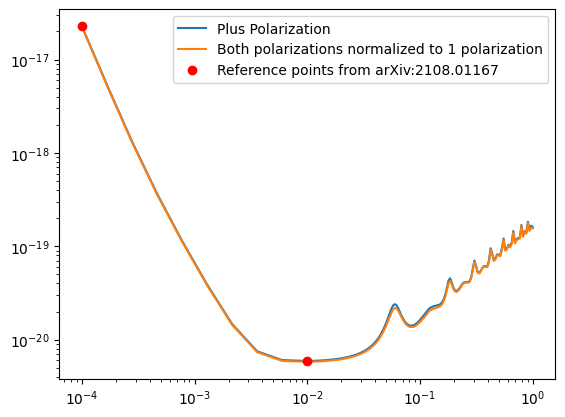

In [3]:
time_ind = 0
plt.figure()
plt.loglog(f, 1/np.mean(h_h_plus[time_ind,:,:],axis=-1)**0.5, label="Plus Polarization")
# plt.loglog(f, 1/np.mean(h_h_cross[time_ind,:,:],axis=-1)**0.5, label="LISA sensitivity Cross Polarization")
plt.loglog(f, np.sqrt(2)/np.mean(h_h[time_ind,:,:],axis=-1)**0.5, label="Both polarizations normalized to 1 polarization")
plt.plot(1e-4, (2.11e-33)**0.5 / 2, 'ro')
plt.plot(1e-2, (1.359e-40)**0.5 / 2 , 'ro', label="Reference points from arXiv:2108.01167")
plt.legend()

# Add time evolution

In [120]:
time_array = np.arange(0, 365, 7) * 86400

# Nominal orbit quantities
# ---------------------------------------------------------------------------
ltts      = orbits.compute_ltt(t=time_array)
positions = orbits.compute_position(t=time_array)
velocities = orbits.compute_velocity(t=time_array)
print(f"Nominal ltts shape: {ltts.shape}  |  positions shape: {positions.shape}  |  velocities shape: {velocities.shape}")

# ---------------------------------------------------------------------------
# HEALPix sky grid
# ---------------------------------------------------------------------------
nside        = 16
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis

# ---------------------------------------------------------------------------
# Nominal strain-to-TDI matrix
# ---------------------------------------------------------------------------
print("Computing nominal strain2x …")
strain2x_nominal = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
print(f"strain2x_nominal shape: {strain2x_nominal.shape}")
cov_AET = compute_covariance(f, ltts)[:,:,np.newaxis,:,:] # added an axis for sky pixels
inv_cov_AET = np.linalg.inv(cov_AET)
print(f"cov_AET shape: {cov_AET.shape}")
strain2AET = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)

# sum over polarizations
h_h = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET), inv_cov_AET, strain2AET).real
# do not sky average
sensitivity = np.sqrt(2)/h_h**0.5
print(f"h_h shape: {h_h.shape}")
print(f"sensitivity shape: {sensitivity.shape}")

Nominal ltts shape: (53, 6)  |  positions shape: (53, 3, 3)  |  velocities shape: (53, 3, 3)
Computing nominal strain2x …
strain2x_nominal shape: (53, 149, 3072, 3, 2)
cov_AET shape: (53, 149, 1, 3, 3)
h_h shape: (53, 149, 3072)
sensitivity shape: (53, 149, 3072)


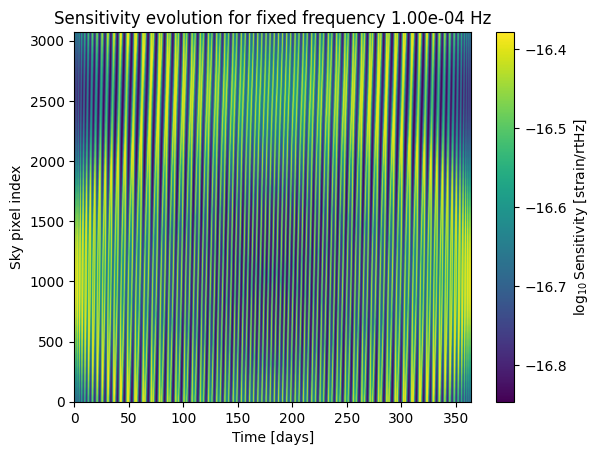

In [122]:
f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
plt.figure()
plt.imshow(np.log10(sensitivity[:,freq_ind,:]), aspect='auto', origin='lower', extent=[time_array[0]/86400, time_array[-1]/86400, 0, npix])
plt.xlabel("Time [days]")
plt.ylabel("Sky pixel index")
plt.title(f"Sensitivity evolution for fixed frequency {f[freq_ind]:.2e} Hz")
plt.colorbar(label=r"$\log_{10}$Sensitivity [strain/rtHz]")
plt.show()

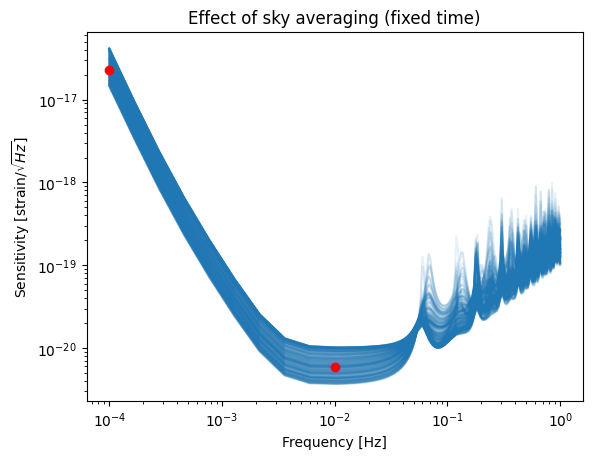

In [145]:
time_ind = 10
plt.figure()
plt.title('Effect of sky averaging (fixed time)')
for sky_pixel in range(0,npix, 10):
    plt.loglog(f, sensitivity[time_ind,:,sky_pixel], color='C0', alpha=0.1)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Sensitivity [strain/$\sqrt{Hz}$]")
plt.plot(1e-4, (2.11e-33)**0.5 / 2, 'ro')
plt.plot(1e-2, (1.359e-40)**0.5 / 2 , 'ro', label="Reference points from arXiv:2108.01167")
plt.show()

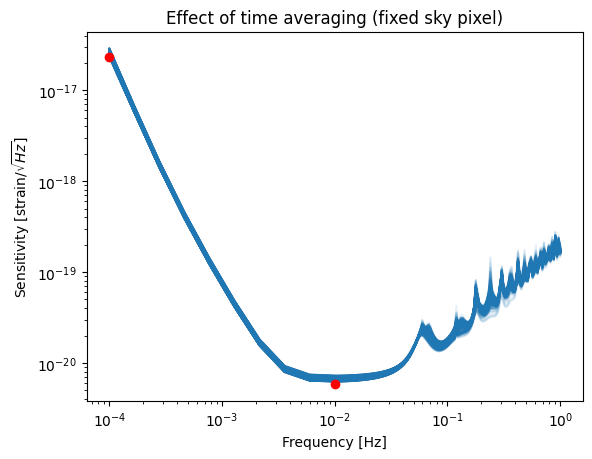

In [146]:
sky_pixel = 10
plt.figure()
plt.title('Effect of time averaging (fixed sky pixel)')
for sky_pixel in range(0,npix, 10):
    plt.loglog(f, np.mean(sensitivity[:,:,sky_pixel],axis=0), color='C0', alpha=0.1)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Sensitivity [strain/$\sqrt{Hz}$]")
plt.plot(1e-4, (2.11e-33)**0.5 / 2, 'ro')
plt.plot(1e-2, (1.359e-40)**0.5 / 2 , 'ro', label="Reference points from arXiv:2108.01167")
plt.show()

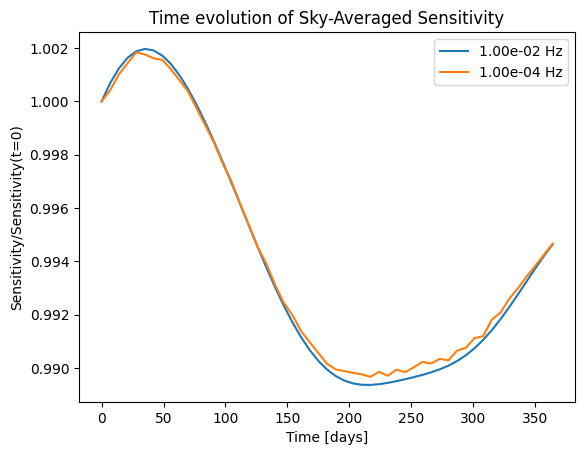

In [128]:

plt.figure()
f_chosen = 1e-2
freq_ind = np.argmin(np.abs(f - f_chosen))
temp_sens_ev = np.mean(sensitivity[:,freq_ind,:], axis=-1)
plt.plot(time_array/86400, temp_sens_ev/temp_sens_ev[0], label=f'{f[freq_ind]:.2e} Hz')
f_chosen = 1e-4
freq_ind = np.argmin(np.abs(f - f_chosen))
temp_sens_ev = np.mean(sensitivity[:,freq_ind,:], axis=-1)
plt.plot(time_array/86400, temp_sens_ev/temp_sens_ev[0], label=f'{f[freq_ind]:.2e} Hz')

plt.xlabel("Time [days]")
plt.ylabel("Sensitivity/Sensitivity(t=0)")
plt.title("Time evolution of Sky-Averaged Sensitivity")
plt.legend()
plt.show()